In [ ]:
# Ireland First Rent Guide (2020–2025)

## Objective
This project analyzes rental trends in Ireland between 2020 and 2025 using official RTB data.  
The goal is to provide practical insights for individuals looking to rent a property in Ireland.

## Business Questions
- What is the average rental cost by county?
- Which counties are the most affordable?
- How have rents evolved from 2020 to 2025?
- Is Dublin significantly more expensive than other counties?
- Where is the best value for money per bedroom?

## Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook


In [2]:
#Importing all necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#Making sure all datasets are imported

try:
    df_full = pd.read_csv('irish_rent_full.csv')
    print("Dataset FULL successfully loaded")
except FileNotFoundError:
    print("Error: file 'irish_rent_full.csv' not found. Check the file path.")

Dataset FULL successfully loaded


In [4]:
#Making sure all datasets are imported

try:
    df_specific = pd.read_csv('irish_rent_specific.csv')
    print("Dataset SPECIFIC successfully loaded")
except FileNotFoundError:
    print("Error: file 'irish_rent_full.csv' not found. Check the file path.")

Dataset SPECIFIC successfully loaded


In [5]:
#Making sure all datasets are imported

try:
    df_county = pd.read_csv('irish_rent_by_county.csv')
    print("Dataset COUNTY successfully loaded")
except FileNotFoundError:
    print("Error: file 'irish_rent_full.csv' not found. Check the file path.")

Dataset COUNTY successfully loaded


In [6]:
#Checking the structure of each dataset

print("COUNTY DATA")
display(df_county.head())
display(df_county.info())

print("SPECIFIC DATA")
display(df_specific.head())
display(df_specific.info())

print("FULL DATA")
display(df_full.head())
display(df_full.info())

COUNTY DATA


,rent_euro,year,half,half_year,time_period,county,province,area,location,property_type,bedrooms,bedrooms_num,is_dublin,is_city,is_county_aggregate
0,835.90,2020,1,2020H1,1,Carlow,Leinster,Carlow,Carlow,All property types,All bedrooms,NaN,False,False,True
1,666.31,2020,1,2020H1,1,Cavan,Ulster,Cavan,Cavan,All property types,All bedrooms,NaN,False,False,True
2,752.02,2020,1,2020H1,1,Clare,Munster,Clare,Clare,All property types,All bedrooms,NaN,False,False,True
3,1095.94,2020,1,2020H1,1,Cork,Munster,Cork,Cork,All property types,All bedrooms,NaN,False,False,True
4,585.60,2020,1,2020H1,1,Donegal,Ulster,Donegal,Donegal,All property types,All bedrooms,NaN,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rent_euro            286 non-null    float64
 1   year                 286 non-null    int64  
 2   half                 286 non-null    int64  
 3   half_year            286 non-null    object 
 4   time_period          286 non-null    int64  
 5   county               286 non-null    object 
 6   province             286 non-null    object 
 7   area                 286 non-null    object 
 8   location             286 non-null    object 
 9   property_type        286 non-null    object 
 10  bedrooms             286 non-null    object 
 11  bedrooms_num         0 non-null      float64
 12  is_dublin            286 non-null    bool   
 13  is_city              286 non-null    bool   
 14  is_county_aggregate  286 non-null    bool   
dtypes: bool(3), float64(2), int64(3), object

None

SPECIFIC DATA


...

None

FULL DATA


,rent_euro,year,half,half_year,time_period,county,province,area,location,property_type,bedrooms,bedrooms_num,is_dublin,is_city,is_county_aggregate
0,835.90,2020,1,2020H1,1,Carlow,Leinster,Carlow,Carlow,All property types,All bedrooms,NaN,False,False,True
1,860.74,2020,1,2020H1,1,Carlow,Leinster,Carlow Town,Carlow Town,All property types,All bedrooms,NaN,False,False,False
2,910.91,2020,1,2020H1,1,Carlow,Leinster,Graiguecullen,"Graiguecullen, Carlow",All property types,All bedrooms,NaN,False,False,False
3,812.14,2020,1,2020H1,1,Carlow,Leinster,Tullow,"Tullow, Carlow",All property types,All bedrooms,NaN,False,False,False
4,666.31,2020,1,2020H1,1,Cavan,Ulster,Cavan,Cavan,All property types,All bedrooms,NaN,False,False,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50208 entries, 0 to 50207
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   rent_euro            50208 non-null  float64
 1   year                 50208 non-null  int64  
 2   half                 50208 non-null  int64  
 3   half_year            50208 non-null  object 
 4   time_period          50208 non-null  int64  
 5   county               50208 non-null  object 
 6   province             50208 non-null  object 
 7   area                 50208 non-null  object 
 8   location             50208 non-null  object 
 9   property_type        50208 non-null  object 
 10  bedrooms             50208 non-null  object 
 11  bedrooms_num         37869 non-null  float64
 12  is_dublin            50208 non-null  bool   
 13  is_city              50208 non-null  bool   
 14  is_county_aggregate  50208 non-null  bool   
dtypes: bool(3), float64(2), int64(3), ob

None

In [12]:
#Selecting the SPECIFIC dataset as the main source for the analysis

df = pd.read_csv("irish_rent_specific.csv")

In [14]:
# Keep only county-level aggregated data

df = df[df['is_county_aggregate'] == True]

In [16]:
# Check how many rows remain

df.shape

(5987, 15)

In [18]:
df['is_county_aggregate'].value_counts()

is_county_aggregate
True    5987
Name: count, dtype: int64

In [20]:
#Inspect key dimensions

print("Unique Counties:", df['county'].nunique())
print("Unique Years:", df['year'].nunique())
print("Unique Halves:", df['half'].unique())
print("Unique Property Types:", df['property_type'].unique())
print("Unique Bedrooms:", sorted(df['bedrooms_num'].unique()))
print("Unique Provinces:", df['province'].unique())


Unique Counties: 26
Unique Years: 6
Unique Halves: [1 2]
Unique Property Types: ['Detached house' 'Semi detached house' 'Terrace house' 'Apartment'
 'Other flats']
Unique Bedrooms: [1.0, 1.5, 2.0, 3.0, 4.0]
Unique Provinces: ['Munster' 'Leinster' 'Connacht' 'Ulster']


In [22]:
# Remove uncommon 1.5 bedroom category for simplicity

df = df[df['bedrooms_num'] != 1.5]

In [24]:
#Check if the 1.5 bedroom category was removed

sorted(df['bedrooms_num'].unique())

[1.0, 2.0, 3.0, 4.0]

In [26]:
# Create simplified property category (original types were too granular for my first analysis)

df['property_category'] = df['property_type'].apply(
    lambda x: 'Apartment' if 'Apartment' in x or 'flat' in x.lower()
    else 'House'
)


In [28]:
#Check the simplified categories

df['property_category'].value_counts()

property_category
House        3147
Apartment    1591
Name: count, dtype: int64

In [30]:
#Start the exploratory analysis with average rent by county, property, bedrooms

avg_table = df.groupby(
    ['county', 'property_category', 'bedrooms_num']
)['rent_euro'].mean().reset_index()

avg_table.head()


,county,property_category,bedrooms_num,rent_euro
0,Carlow,Apartment,1.0,772.155556
1,Carlow,Apartment,2.0,871.510625
2,Carlow,Apartment,3.0,1010.493000
3,Carlow,Apartment,4.0,1355.345000
4,Carlow,House,2.0,913.515745


In [32]:
avg_table.shape


(163, 4)

In [34]:
#Most expensive counties (overall)

county_avg = df.groupby('county')['rent_euro'].mean().sort_values(ascending=False)
county_avg.head(10)

#Insight 1: Dublin is dramatically higher than the second place (€584 on average)

county
Dublin       1990.532463
Wicklow      1406.255276
Kildare      1386.424899
Meath        1244.572383
Galway       1216.109348
Cork         1207.744821
Louth        1182.006562
Limerick     1129.947593
Carlow        974.093155
Westmeath     958.916704
Name: rent_euro, dtype: float64

In [36]:
#Cheapest rents (overall)

county_avg.tail(10)

#Insight 2: Dublin is almost 3x more expensive than Donegal on average

county
Sligo        867.505500
Clare        859.768226
Tipperary    812.890711
Longford     799.499185
Roscommon    798.299145
Mayo         794.433141
Cavan        777.643353
Monaghan     771.637075
Leitrim      713.594513
Donegal      676.610365
Name: rent_euro, dtype: float64

In [38]:
#Cheapest 1-Bed Apartments

one_bed_apts = avg_table[
    (avg_table['property_category'] == 'Apartment') &
    (avg_table['bedrooms_num'] == 1)
]

one_bed_apts.sort_values('rent_euro').head(10)


,county,property_category,bedrooms_num,rent_euro
26,Donegal,Apartment,1.0,530.052727
73,Leitrim,Apartment,1.0,546.392857
12,Clare,Apartment,1.0,561.607273
7,Cavan,Apartment,1.0,588.005714
132,Tipperary,Apartment,1.0,605.525909
97,Mayo,Apartment,1.0,609.282105
120,Roscommon,Apartment,1.0,624.570000
110,Monaghan,Apartment,1.0,626.980714
85,Longford,Apartment,1.0,649.537273
48,Kerry,Apartment,1.0,662.647143


In [40]:
#Cheapest 2-Bed Houses

two_bed_houses = avg_table[
    (avg_table['property_category'] == 'House') &
    (avg_table['bedrooms_num'] == 2)
]

two_bed_houses.sort_values('rent_euro').head(10)

#Insight 3: Rural counties have much lower price scaling
#Insight 4: Urban premium is massive

,county,property_category,bedrooms_num,rent_euro
29,Donegal,House,2.0,668.724262
75,Leitrim,House,2.0,698.327714
112,Monaghan,House,2.0,758.677447
88,Longford,House,2.0,759.735745
9,Cavan,House,2.0,762.248136
123,Roscommon,House,2.0,772.039672
100,Mayo,House,2.0,781.020606
135,Tipperary,House,2.0,802.277273
129,Sligo,House,2.0,813.980492
15,Clare,House,2.0,853.832381


In [42]:
one_bed_apts[one_bed_apts['county'] == 'Dublin']


,county,property_category,bedrooms_num,rent_euro
32,Dublin,Apartment,1.0,1369.856364


In [44]:
dublin_1bed = one_bed_apts[
    one_bed_apts['county'] == 'Dublin'
]['rent_euro'].values[0]

one_bed_apts['difference_vs_dublin'] = (
    (dublin_1bed - one_bed_apts['rent_euro']) / dublin_1bed
) * 100

one_bed_apts.sort_values('difference_vs_dublin', ascending=False).head()

#Insight 5: Living in Donegal is 61% cheaper than Dublin for a 1-bed apartment

/var/folders/vr/r3j9wynd0vz1_v8kjzd8ml4w0000gq/T/ipykernel_16698/1811050098.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  one_bed_apts['difference_vs_dublin'] = (


,county,property_category,bedrooms_num,rent_euro,difference_vs_dublin
26,Donegal,Apartment,1.0,530.052727,61.305963
73,Leitrim,Apartment,1.0,546.392857,60.113128
12,Clare,Apartment,1.0,561.607273,59.002470
7,Cavan,Apartment,1.0,588.005714,57.075374
132,Tipperary,Apartment,1.0,605.525909,55.796394


In [46]:
#Trend Analysis (Dublin x Donegal)

trend_dublin = df[df['county'] == 'Dublin'] \
    .groupby('year')['rent_euro'].mean()

trend_donegal = df[df['county'] == 'Donegal'] \
    .groupby('year')['rent_euro'].mean()

trend_dublin

#Insight 6: Dublin rents increased ~26% in 5 years

year
2020    1804.952653
2021    1857.847200
2022    1941.568571
2023    2038.552292
2024    2173.608125
2025    2283.629167
Name: rent_euro, dtype: float64

In [48]:
trend_donegal

#Insight 7: Donegal rents increased ~63% in 5 years
#Insight 8: Donegal is growing much faster in percentage terms
#Insight 9: Rural catch-up effect
#Insight 10: Possible supply shortages spreading
#Insight 11: Post-COVID relocation trends
#Insight 12: Price pressure expanding beyond cities

year
2020    546.739167
2021    572.430833
2022    637.146389
2023    720.056765
2024    820.972353
2025    892.925625
Name: rent_euro, dtype: float64

In [50]:
#Calculate growth rate per county

growth = df.groupby(['county', 'year'])['rent_euro'].mean().reset_index()

growth_pivot = growth.pivot(index='county', columns='year', values='rent_euro')

growth_pivot['growth_%'] = (
    (growth_pivot[2025] - growth_pivot[2020]) /
    growth_pivot[2020]
) * 100

growth_pivot.sort_values('growth_%', ascending=False).head(10)


year,2020,2021,2022,2023,2024,2025,growth_%
county,,,,,,,
Leitrim,565.464783,613.299048,686.751304,754.965500,886.023889,988.523750,74.816148
Longford,647.233333,684.663571,754.640000,849.339600,1009.248095,1110.312222,71.547441
Cavan,631.028750,655.535000,732.125484,820.528065,934.063548,1076.603333,70.610821
Monaghan,640.453667,663.640357,739.615769,809.435556,915.815200,1059.541818,65.436139
Roscommon,645.384000,691.122500,758.192069,847.017931,976.585200,1060.254545,64.282744
Donegal,546.739167,572.430833,637.146389,720.056765,820.972353,892.925625,63.318394
Mayo,654.062500,683.340000,753.646857,835.879722,950.829687,1043.398750,59.525848
Kerry,733.462973,773.800811,860.809722,918.745588,1030.172059,1137.786000,55.125213
Offaly,767.711250,810.254375,888.139333,958.202759,1092.749600,1182.700000,54.055317


In [52]:
# Create date variable using year and half-year

df['date'] = pd.to_datetime(
    df['year'].astype(str) + '-' +
    df['half'].map({1: '01', 2: '07'})
)


In [54]:
# Save cleaned dataset for Tableau
df.to_csv("final_rent_data.csv", index=False)


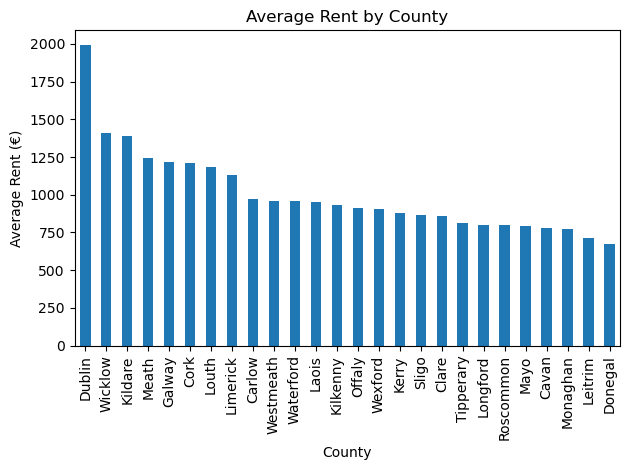

In [56]:
plt.figure()
county_avg.plot(kind="bar")

plt.title("Average Rent by County (2020-2025")
plt.ylabel("Average Rent (€)")
plt.xlabel("County")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#Insight 13:Dublin has the highest average rent, significantly above all other counties.
#Insight 14: Western counties such as Donegal and Leitrim present the lowest rental costs (strong regional price imbalance).

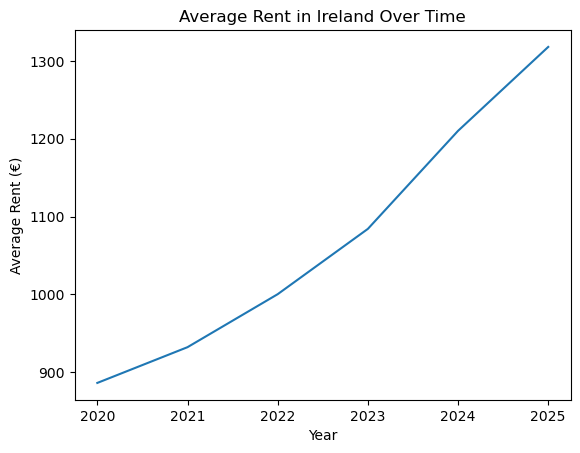

In [64]:
year_avg = df.groupby("year")["rent_euro"].mean()

plt.figure()
plt.plot(year_avg.index, year_avg.values)
plt.title("Average Rent in Ireland Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rent (€)")
plt.show()

#Insight 15: Rental prices have increased consistently between 2020 and 2025.
#Insight 16: The growth accelerates after 2022, indicating post-pandemic housing pressure.

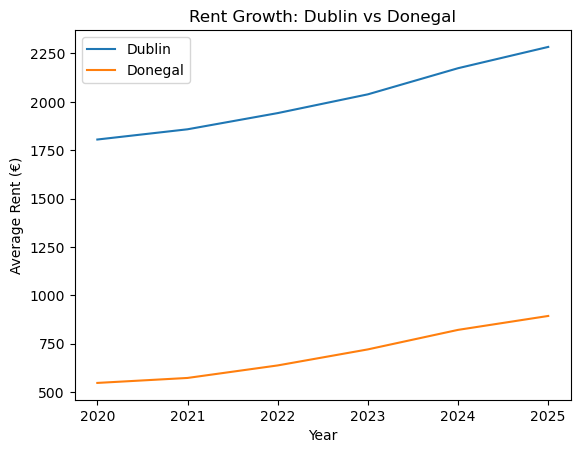

In [58]:
dublin = df[df["county"] == "Dublin"]
donegal = df[df["county"] == "Donegal"]

dublin_year = dublin.groupby("year")["rent_euro"].mean()
donegal_year = donegal.groupby("year")["rent_euro"].mean()

plt.figure()
plt.plot(dublin_year.index, dublin_year.values)
plt.plot(donegal_year.index, donegal_year.values)

plt.title("Rent Growth: Dublin vs Donegal")
plt.xlabel("Year")
plt.ylabel("Average Rent (€)")
plt.legend(["Dublin", "Donegal"])

plt.show()

#Insight 16: While both counties show growth, Dublin’s price level remains dramatically higher.
#Insight 17: Relative growth in lower-cost counties is proportionally strong.

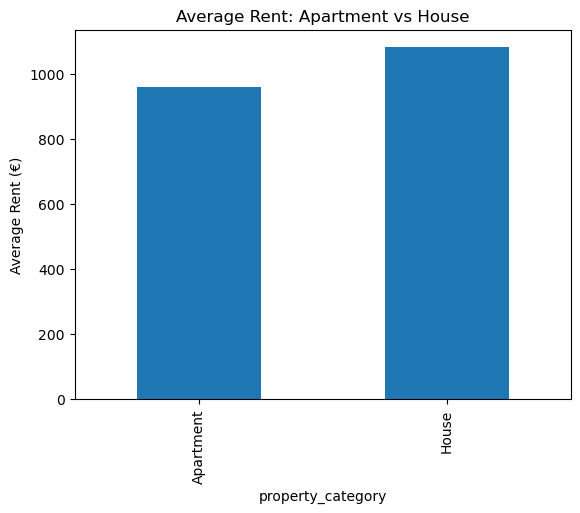

In [60]:
category_avg = (
    df.groupby("property_category")["rent_euro"]
    .mean()
)

plt.figure()
category_avg.plot(kind="bar")

plt.title("Average Rent: Apartment vs House")
plt.ylabel("Average Rent (€)")
plt.show()

#Insight 18: 

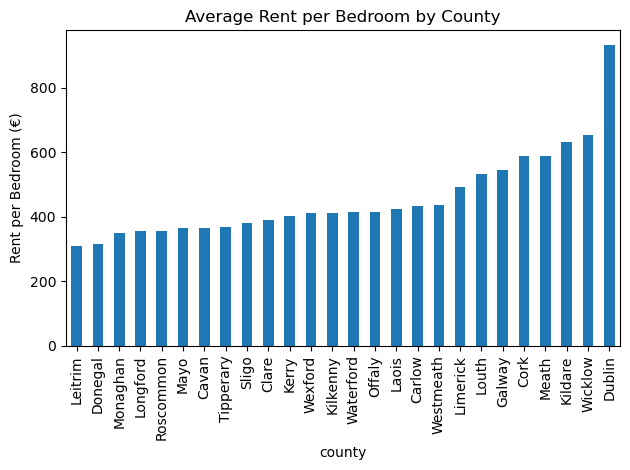

In [66]:
df["rent_per_bedroom"] = df["rent_euro"] / df["bedrooms_num"]

value_avg = (
    df.groupby("county")["rent_per_bedroom"]
    .mean()
    .sort_values()
)

plt.figure()
value_avg.plot(kind="bar")
plt.title("Average Rent per Bedroom by County")
plt.ylabel("Rent per Bedroom (€)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

#Insight 19: Counties in the west offer significantly better value compared to Dublin and surrounding counties.

In [ ]:
# Final Conclusions

- Dublin remains the most expensive rental market in Ireland.
- Rental prices increased steadily from 2020 to 2025.
- Regional disparities remain significant.
- Western counties offer the best value per bedroom.
- Smaller counties are more affordable but still experiencing growth.

This analysis provides a data-driven guide for individuals considering renting in Ireland.
